In [3]:
#Load data
import pandas as pd
DATA_PATH = r"../data/entraineddropletfraction_VerticalFlow.csv"
df = pd.read_csv(DATA_PATH)

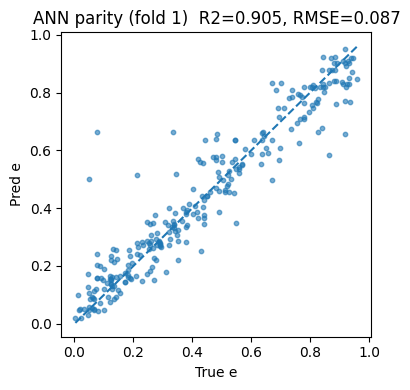

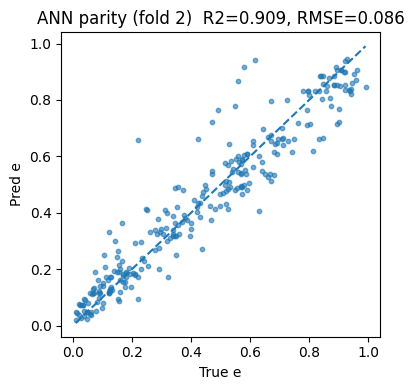

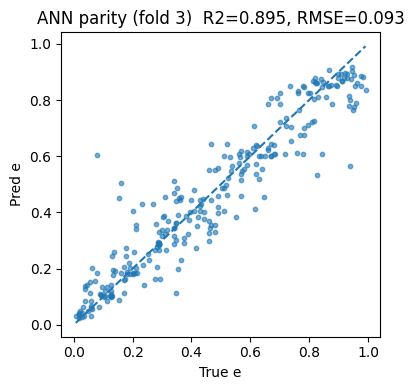

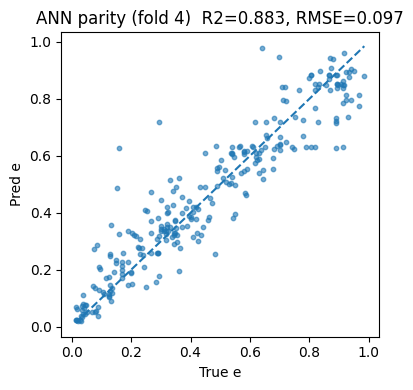

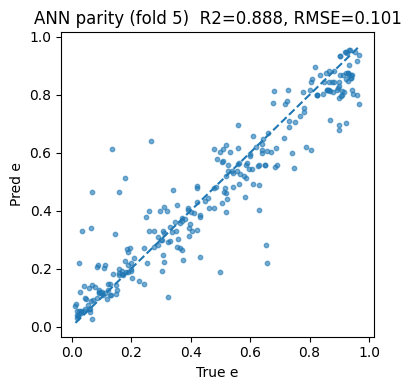

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


ANN 5-fold CV → RMSE: 0.093 ± 0.006, R²: 0.896 ± 0.011


  0%|          | 0/274 [00:00<?, ?it/s]

ipykernel_37604\3800013700.py:130: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


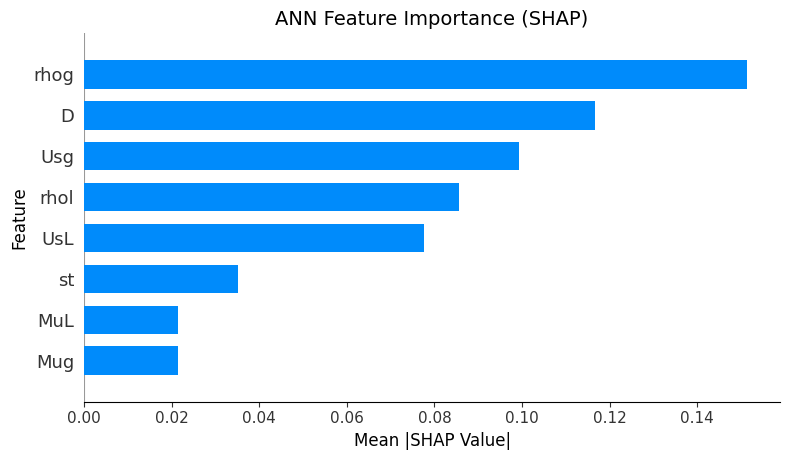

ipykernel_37604\3800013700.py:145: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


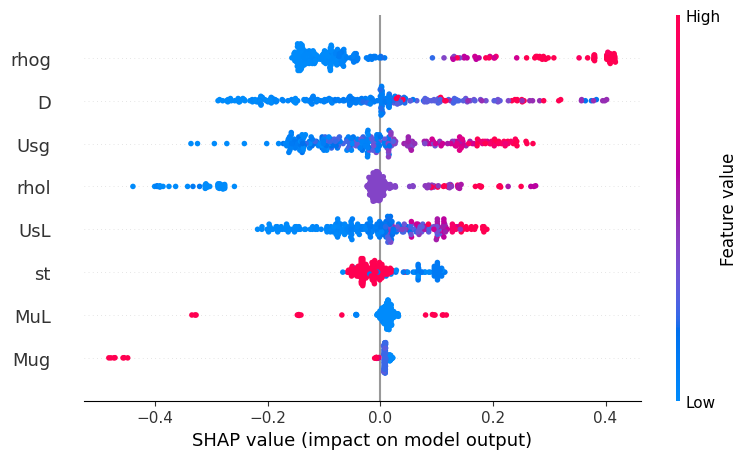

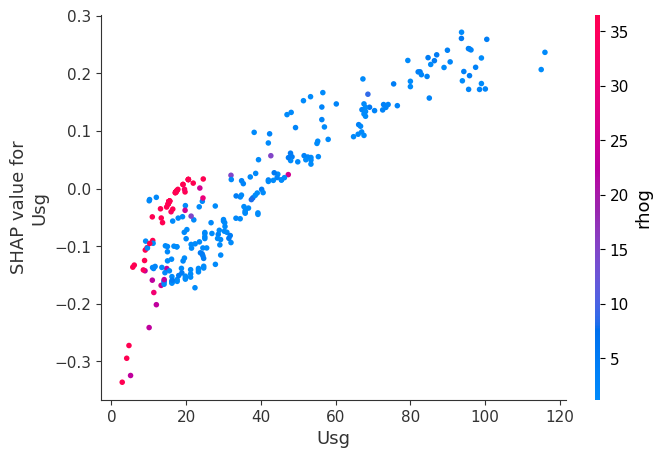

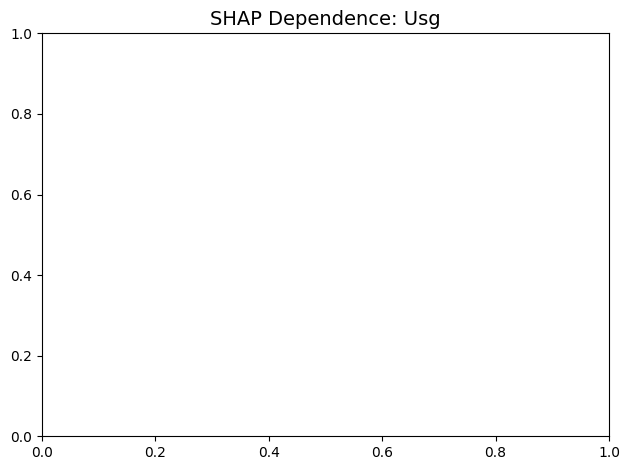

In [ ]:
#ANN with 5 fold CV & SHAP on best fold 

#imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import shap

torch.set_grad_enabled(True)
SEED = 42 #Seed 42 on all models
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #using RTX 4070

#Data
feature_cols = ['D','Usg','UsL','rhol','rhog','st','MuL','Mug'] #8 Features
X = df[feature_cols].to_numpy().astype(np.float32)
y = df['e'].to_numpy().astype(np.float32).reshape(-1,1)

# Model definition
class MLP(nn.Module):
    def __init__(self, in_dim=8, h=[32,16], act="tanh"):
        super().__init__()
        A = {"relu": nn.ReLU(), "tanh": nn.Tanh(), "sigmoid": nn.Sigmoid()}[act]  #activation
        layers, prev = [], in_dim
        for k in h:
            fc = nn.Linear(prev, k); nn.init.xavier_uniform_(fc.weight); nn.init.zeros_(fc.bias) #Xavier init
            layers += [fc, A]; prev = k
        out = nn.Linear(prev, 1); nn.init.xavier_uniform_(out.weight); nn.init.zeros_(out.bias)
        self.body = nn.Sequential(*layers)
        self.out  = nn.Sequential(out, nn.Sigmoid())  # ensures ê ∈ [0,1]
    def forward(self, x): return self.out(self.body(x))
# Training function for a single fold
def train_fold(Xtr, ytr, Xte, epochs=1500, lr=1e-3, wd=1e-4, bs=128): #

    # scale inputs (no target scaling)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s = scaler.transform(Xtr)
    Xte_s = scaler.transform(Xte)

    Xt = torch.tensor(Xtr_s, dtype=torch.float32, device=device)
    yt = torch.tensor(ytr,   dtype=torch.float32, device=device)
    Xs = torch.tensor(Xte_s, dtype=torch.float32, device=device)

    model = MLP(in_dim=Xt.shape[1], h=[32,16], act="tanh").to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.MSELoss()

    # mini-batch training
    N = Xt.shape[0]
    for _ in range(epochs):
        model.train()
        idx = torch.randperm(N, device=device)
        for b in range(0, N, bs):
            sel = idx[b:b+bs]
            opt.zero_grad()
            yhat = model(Xt[sel])
            loss = lossf(yhat, yt[sel])
            loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        yhat = model(Xs).cpu().numpy().ravel()
    return yhat, model, scaler, Xtr_s, Xte_s

#Five fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
rows, fold = [], 1
best = {"r2": -1, "artifacts": None}
# CV loop
for tr, te in kf.split(X):
    yhat, model, scaler, Xtr_s, Xte_s = train_fold(X[tr], y[tr], X[te], epochs=1500, lr=1e-3, wd=1e-4, bs=128)
    yte = y[te].ravel()
    mse  = mean_squared_error(yte, yhat)
    rmse = np.sqrt(mse)
    r2   = r2_score(yte, yhat)
    rows.append((rmse, r2))

    # quick parity per fold
    plt.figure(figsize=(4,4))
    plt.scatter(yte, yhat, s=10, alpha=0.6)
    lo, hi = float(min(yte.min(), yhat.min())), float(max(yte.max(), yhat.max()))
    plt.plot([lo,hi],[lo,hi],'--')
    plt.title(f"ANN parity (fold {fold})  R2={r2:.3f}, RMSE={rmse:.3f}")
    plt.xlabel("True e"); plt.ylabel("Pred e"); plt.tight_layout(); plt.show()

    # keep best fold artifacts for SHAP
    if r2 > best["r2"]:
        best["r2"] = r2
        best["artifacts"] = (model, scaler, tr, te, Xtr_s, Xte_s)
    fold += 1
#CV Summary
rmses = np.array([r[0] for r in rows])
r2s   = np.array([r[1] for r in rows])
print(f"ANN 5-fold CV → RMSE: {rmses.mean():.3f} ± {rmses.std(ddof=1):.3f}, "
      f"R²: {r2s.mean():.3f} ± {r2s.std(ddof=1):.3f}")

#SHAP on best fold
model, scaler, tr_idx, te_idx, Xtr_s, Xte_s = best["artifacts"]
model.eval()

# background (small for speed) & evaluation tensors (scaled)
bg_sel = np.random.default_rng(SEED).choice(len(Xtr_s), size=min(200, len(Xtr_s)), replace=False)
X_bg  = torch.tensor(Xtr_s[bg_sel], dtype=torch.float32, device=device)
X_exp = torch.tensor(Xte_s,        dtype=torch.float32, device=device)

# SHAP KernelExplainer (model-agnostic)
# Model prediction function for SHAP
def predict_fn(x_np):
    with torch.no_grad():
        xt = torch.tensor(x_np, dtype=torch.float32, device=device)
        return model(xt).cpu().numpy().ravel()

# Background (scaled) and evaluation set (scaled)
bg_small = Xtr_s[bg_sel]                      # 200 background samples
exp_small = Xte_s[:500]                       # limit for runtime

# SHAP KernelExplainer
explainer = shap.KernelExplainer(predict_fn, bg_small)
shap_vals = explainer.shap_values(exp_small, nsamples="auto")

# Convert back to original feature units for plotting
X_display = pd.DataFrame(
    scaler.inverse_transform(exp_small),
    columns=feature_cols
)

#SHAP Bar Plot (clean labels)
shap.summary_plot(
    shap_vals,
    X_display,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)

plt.title("ANN Feature Importance (SHAP)", fontsize=14)
plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

#SHAP Full Summary Plot
shap.summary_plot(
    shap_vals,
    X_display,
    feature_names=feature_cols,
    show=True
)


A compact feed-forward artificial neural network with two hidden layers (32–16 neurons, tanh activation, weight decay = 1e-4) achieved consistent performance across the five cross-validation folds, with a mean R² ≈ 0.90 and RMSE ≈ 0.093 The parity plots show tight alignment with the 45° line, indicating that the model captures the dominant nonlinear trends between the flow parameters and the entrained liquid fraction (e). Prediction errors are centered near zero and remain approximately uniform across the range of e, suggesting good bias control and stable generalization.

SHAP analysis confirms that the network’s behavior is physically coherent: gas density (rhog), pipe diameter (D), and gas velocity (Usg) exert the largest positive influence on predicted entrainment, while liquid-phase properties (rhol, UsL) play a secondary but consistent role. These dependencies agree with physical expectations that higher gas inertia and larger conduits promote droplet carryover. 

Compared with classical regression and tree-based baselines, the ANN achieves comparable accuracy with smoother and more interpretable response patterns. Overall, the model demonstrates that a small, well-regularized neural network can effectively reproduce the key physics of entrainment while retaining flexibility.